# DP multi-component workflow (test)

Mirrors `dp_workflow.ipynb` but drives the refactored `src/DP_new.py`.
Key API changes vs. the old two-component `DP`:

- `fit_all` returns **`(dp_parent, dp_components, model_cube)`** instead of L/R arrays.
- `dp_parent`: one scalar row per galaxy (Z, mass, chosen `N_COMP`, BIC/chi2 per N, total flux per line).
- `dp_components`: **tidy/long** table, one row per (target, component, line).
- `bpt_classification` / `estimate_SFR` / `select_dp_sample` consume `dp_components`.
- `plot_fit` overlays every component for a target.

In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP_new import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
# new-schema output catalogs (parent + components + model cube live in one FITS each)
filenames = {
    'all' : './catalogs/test_all_multicomp_0722.fits',
    'dps' : './catalogs/test_dps_multicomp_0722.fits',
}

## Build the sample: keep sources with >=1 significant emission line (>5 S/N)

In [4]:
FIT = FitSpectrum()
DP  = DP()

ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=None, subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 41.14 seconds.
Total number of spectra: 99812


In [5]:
ALL_SPECTRA = FIT.label_emission_lines(ALL_SPECTRA, 5)
ALL_SPECTRA = FIT.significant_emission_filter(ALL_SPECTRA)
print('After significant-emission filter:', len(ALL_SPECTRA.targetID))

After significant-emission filter: 57271


In [6]:
# --- TEST MODE: thin the sample so a full 1..4-component fit runs quickly ---
# Comment this out for a production run.
# ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(10)
# print('After shrinking:', len(ALL_SPECTRA.targetID))

In [7]:
ALL_SPECTRA.df.head()

,TARGETID,RA,DEC,Z,SPECTYPE,LOGM,LOGSFR,OII,Hbeta,OIII,Halpha,NII,SII
0,39627739380056197,177.003822,-1.903397,0.224113,GALAXY,10.250155,-0.348563,False,False,False,True,False,False
1,39627739380056420,177.013472,-1.972766,0.102005,GALAXY,9.722920,-0.349153,False,False,False,True,False,False
2,39627739380056564,177.019312,-1.965308,0.323187,GALAXY,10.452706,0.941032,False,False,False,True,True,True
3,39627739380056768,177.028143,-1.960056,0.102814,GALAXY,10.143390,0.193251,True,False,False,True,True,True
4,39627739380056864,177.032977,-1.909970,0.167324,GALAXY,10.575973,-9.632146,False,False,False,True,True,False


## Fit everything
For each target, `fit_dp` fits N = 1..4 velocity components, picks N by minimum BIC,
and emits a scalar parent row + tidy per-(component, line) rows + the best-fit model.

In [8]:
dp_parent, dp_components, model_cube = DP.fit_all(data_class=ALL_SPECTRA, n_jobs=10)
print('parent    :', dp_parent.shape)
print('components:', dp_components.shape)
print('model cube:', model_cube.shape)
print('N_COMP distribution:')
print(dp_parent['N_COMP'].value_counts().sort_index())

100%|██████████| 57271/57271 [1:16:45<00:00, 12.44it/s]


parent    : (57271, 26)
components: (757990, 14)
model cube: (57271, 7781)
N_COMP distribution:
N_COMP
1    40738
2    14682
3     1707
4      144
Name: count, dtype: int64


In [9]:
dp_parent[dp_parent['N_COMP']==1].head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3726_FLUX_TOT,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT
0,39627739380056197,177.003815,-1.903397,0.224113,10.250154,-0.348563,1,1,807.014282,746.630554,...,2.234996,2.974765,2.358496,0.383114,1.160451,1.938171,5.943389,14.052762,1.258454,2.053484
1,39627739380056420,177.013474,-1.972766,0.102005,9.722919,-0.349153,1,1,749.587891,690.067444,...,2.793715,3.718417,3.139801,0.486163,1.472587,1.361834,4.176056,15.036660,4.805563,0.152118
2,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,1,1,945.812256,884.752136,...,6.948430,9.248314,5.847883,3.138156,9.505467,4.574344,14.027197,34.161682,6.503980,4.075816
3,39627739380056768,177.028137,-1.960056,0.102814,10.143390,0.193251,1,1,778.641907,719.194214,...,9.519390,12.670244,11.370088,3.000140,9.087414,6.037732,18.514666,59.799660,13.045617,10.133431
4,39627739380056864,177.032974,-1.909970,0.167324,10.575974,-9.632146,1,1,842.335876,782.310425,...,4.496522,5.984840,6.231288,1.670815,5.060894,7.304664,22.399704,31.581425,8.945648,7.590320


## Persist to FITS and round-trip

In [10]:
DP.get_catalog(dp_parent, dp_components, model_cube, fname=filenames['all'])


In [11]:

dp_parent, dp_components, model_cube = DP.extract_fits_data(filenames['all'])
print('reloaded:', dp_parent.shape, dp_components.shape, model_cube.shape)

reloaded: (57271, 26) (757990, 14) (57271, 7781)


## Per-component science: BPT and SFR
Both now return one result **per component** instead of a fixed L/R pair.

In [12]:
bpt = DP.bpt_classification(dp_components)
# attach the class back onto the component rows
dp_components = dp_components.merge(bpt, on=['TARGETID', 'COMP_IDX'], how='left')
bpt.head(10)

/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:621: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classify)


,TARGETID,COMP_IDX,BPT,OIII_HB_BOUND,NII_HA_BOUND
0,39627739380056197,0,1,uncertain,upper_limit
1,39627739380056420,0,1,uncertain,upper_limit
2,39627739380056564,0,4,lower_limit,measured
3,39627739380056768,0,1,measured,measured
4,39627739380056864,0,4,uncertain,measured
5,39627739380057310,0,1,measured,upper_limit
6,39627739380057506,0,4,uncertain,measured
7,39627739380057763,0,1,uncertain,measured
8,39627739380057763,1,4,upper_limit,measured
9,39627739380058028,0,1,upper_limit,measured


In [13]:
per_comp_sfr, dp_parent = DP.estimate_SFR(dp_components, dp_parent)
print('total SFR written to parent as LOGSFR_FIT')
per_comp_sfr.head()

/Users/hyp0515/master_project/code/main/nature_of_DP/src/misc.py:235: RuntimeWarning: overflow encountered in scalar power
  flux_intrinsic = flux_halpha / (10**(A_halpha/-2.5)) * 1e-17
/Users/hyp0515/master_project/code/main/nature_of_DP/src/misc.py:229: RuntimeWarning: divide by zero encountered in log10
  ebv = 1.97 * np.log10((flux_halpha/flux_hbeta) / flux_ratio)


total SFR written to parent as LOGSFR_FIT


/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:1032: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(comp_sfr)


,TARGETID,COMP_IDX,SFR,LOGSFR
0,39627739380056197,0,0.737449,-0.132268
1,39627739380056420,0,0.099626,-1.001626
2,39627739380056564,0,5.910387,0.771616
3,39627739380056768,0,0.515609,-0.287679
4,39627739380056864,0,0.751430,-0.124111


## Select the multi-component (DP+) sample
A galaxy qualifies when its best model has >1 component AND >=2 components are
significantly detected (`SIG`) in the same line.

In [14]:
dp_sample = DP.select_dp_sample(dp_parent, dp_components)
print('DP+ candidates:', len(dp_sample), '/', len(dp_parent))
# save the DP+ subset (parent rows + their component rows + their model slices)
mask = dp_parent['TARGETID'].isin(dp_sample['TARGETID'])
DP.get_catalog(dp_sample,
               dp_components[dp_components['TARGETID'].isin(dp_sample['TARGETID'])],
               model_cube[mask.to_numpy()],
               fname=filenames['dps'])
# dp_sample.sort_values('N_COMP_FIT', ascending=True).head(50)
dp_sample[dp_sample['N_COMP_FIT'] == 4].head(50)

DP+ candidates: 16144 / 57271


,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT,LOGSFR_FIT
81,39627739405223617,178.571960,-1.932314,0.305112,10.510936,1.428659,4,4,2235.995117,2174.996338,...,103.936150,100.574997,45.449909,137.667648,45.318306,138.968292,413.442719,72.765480,56.237263,1.401728
117,39627739417808986,179.424606,-1.983819,0.224270,9.888641,1.483569,4,4,1475.027588,1414.687866,...,55.118233,60.929974,28.811142,87.268867,41.540249,127.382896,265.006531,42.189075,18.946650,1.326362
488,39627739581387249,189.229843,-1.983804,0.090756,9.466395,-0.712113,4,4,5610.039551,5550.702148,...,60.676857,122.208282,117.613121,356.249786,35.523846,108.933640,482.548737,25.921484,19.892229,0.554579
763,39627739677856750,194.987213,-1.948047,0.263218,11.140140,1.411261,4,4,1532.908936,1472.180664,...,29.068937,27.349802,46.683475,141.404114,45.673313,140.056915,123.537437,22.993217,27.291620,1.152384
1354,39627739900152195,208.097778,-1.946778,0.166847,10.860261,-0.254328,4,4,2451.696045,2391.762207,...,294.263855,123.115990,196.901810,596.415039,100.446754,308.019318,525.631287,167.122574,153.236649,0.862570
1457,39627739937902327,210.444656,-1.899289,0.131184,10.098392,1.023593,4,4,2225.707764,2165.948730,...,86.290077,126.942047,51.622284,156.363754,83.443062,255.877609,507.635315,94.223289,76.711121,1.056795
1471,39627739946287571,210.767715,-1.894657,0.174390,10.527916,1.772754,4,4,2160.485840,2100.380859,...,54.368950,77.294502,26.786077,81.134949,83.310539,255.471222,418.149170,84.036278,65.074661,1.216032
2889,39627745600209940,187.806992,-1.764181,0.283906,10.982166,-8.216452,4,4,1670.350342,1609.475342,...,65.164719,58.027321,45.437103,137.628845,49.817356,152.764603,487.956207,73.649994,66.640221,2.254347
3138,39627745646350987,190.744324,-1.791006,0.111824,9.617455,1.265703,4,4,3905.034424,3845.489990,...,84.837791,77.488213,205.585663,622.718384,50.212406,153.976013,295.206512,58.664944,57.281834,0.782057
3441,39627745692484090,193.271576,-1.757273,0.216280,9.742699,1.611851,4,4,6570.481934,6510.076660,...,145.041458,150.534851,59.894398,181.419952,71.182243,218.279877,624.669434,78.895515,64.301720,1.298885


In [15]:
dp_components[(dp_components['N_COMP']==2)
              & (dp_components['SIGMA']>60)
              & (dp_components['LINE']=='Halpha')
              & (dp_components['SIG']==True)
              & (dp_components['BPT']==16) 
              & (dp_components['OIII_HB_BOUND'] == 'measured')
              & (dp_components['NII_HA_BOUND'] == 'measured')
              & (np.abs(dp_components['DV'])<80)
              ].sort_values('SIGMA', ascending=True).head(50)

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3,COMP_INSIG,BPT,OIII_HB_BOUND,NII_HA_BOUND
315507,39627775820173645,2,1,Halpha,6564.631836,79.866241,62.299397,28.628250,97.920570,4.761965,34.360241,True,8.549467,False,16,measured,measured
434157,39627788017209863,2,0,Halpha,6564.631836,2.041569,62.329563,11.408727,39.031376,2.971144,13.951503,True,8.392940,False,16,measured,measured
442047,39627788130453117,2,1,Halpha,6564.631836,61.828484,62.757809,24.742256,85.246437,2.697825,30.643181,True,8.345717,False,16,measured,measured
662457,39627812423860350,2,1,Halpha,6564.631836,0.508892,63.480713,51.936634,180.965576,4.252163,46.519817,True,11.670225,False,16,measured,measured
577147,39627805897526727,2,1,Halpha,6564.631836,1.314743,63.854904,22.773109,79.817497,4.054466,36.173405,True,6.619573,False,16,measured,measured
60807,39627745898008834,2,1,Halpha,6564.631836,0.160502,64.131821,19.634678,69.115776,1.940058,21.952929,True,9.445087,False,16,measured,measured
471727,39627793796957324,2,1,Halpha,6564.631836,0.467273,64.353775,9.937663,35.102539,2.737630,11.327250,True,9.296840,False,16,measured,measured
410977,39627782434589057,2,0,Halpha,6564.631836,-47.619194,64.890221,126.394241,450.108429,4.660055,136.920486,True,9.862113,False,16,measured,measured
594077,39627806178542166,2,1,Halpha,6564.631836,4.991337,65.174858,32.000992,114.480202,2.913565,30.037670,True,11.433663,False,16,measured,measured
269207,39627769948148377,2,1,Halpha,6564.631836,2.026238,65.432098,45.902248,164.856979,2.835070,63.945198,True,7.734293,False,16,measured,measured


In [16]:
line = 'Halpha'

sub = dp_components[
    (dp_components['TARGETID'].isin(dp_sample[dp_sample['N_COMP_FIT'] == 4]['TARGETID']))
    & ((dp_components['LINE'] == 'Halpha') & (dp_components['SIG'] == True))
    # & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
    # & (dp_components['BPT'] == 16)
    # & (np.abs(dp_components['DV']) > 90)
    & (dp_components['OIII_HB_BOUND'] != 'uncertain')
    & (dp_components['NII_HA_BOUND'] != 'uncertain')
    # & (dp_components['OIII_HB_BOUND'] == 'measured')
    # & (dp_components['NII_HA_BOUND'] == 'measured')
]


sub_oiii = dp_components[
    (dp_components['TARGETID'].isin(dp_sample[dp_sample['N_COMP_FIT'] == 4]['TARGETID']))
    & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
    # & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
    # & (dp_components['BPT'] == 16)
    # & (np.abs(dp_components['DV']) > 90)
    # & (dp_components['OIII_HB_BOUND'] != 'uncertain')
    # & (dp_components['NII_HA_BOUND'] != 'uncertain')
    # & (dp_components['OIII_HB_BOUND'] == 'measured')
    # & (dp_components['NII_HA_BOUND'] == 'measured')
]


dv_ = sub.pivot(index='TARGETID', columns='COMP_IDX', values='DV')
sigma_ = sub.pivot(index='TARGETID', columns='COMP_IDX', values='SIGMA')
amp_ = sub.pivot(index='TARGETID', columns='COMP_IDX', values='AMP')


dv_oiii_ = sub_oiii.pivot(index='TARGETID', columns='COMP_IDX', values='DV')
sigma_oiii_ = sub_oiii.pivot(index='TARGETID', columns='COMP_IDX', values='SIGMA')
amp_oiii_ = sub_oiii.pivot(index='TARGETID', columns='COMP_IDX', values='AMP')


In [17]:
dv_oiii_[(sigma_oiii_[0]*sigma_oiii_[1]*sigma_oiii_[2]*sigma_oiii_[3]>0)].head(50)

COMP_IDX,0,1,2,3
TARGETID,,,,
39627739405223617,-259.710022,-19.860909,234.008636,389.023987
39627739417808986,-32.688427,-25.426758,46.872677,61.915100
39627745600209940,-104.947243,-11.076860,97.224571,208.132858
39627745646350987,-153.111038,-86.335831,7.633265,71.998093
39627745692484090,-37.051731,-10.255609,16.762743,34.643379
39627745776372740,-285.961060,-72.466156,-8.554685,189.696457
39627745818317047,-279.531769,-90.636246,55.225929,106.106865
39627751816168436,-139.684677,-19.530184,-5.576360,122.000252
39627751879086086,-67.194839,-12.688457,37.733013,138.212784


In [18]:
len(dv_oiii_[(sigma_oiii_[0]*sigma_oiii_[1]*sigma_oiii_[2]*sigma_oiii_[3]>0)])

65

In [19]:
dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0)].head(50)

COMP_IDX,0,1,2,3
TARGETID,,,,
39627739405223617,-259.710022,-19.860909,234.008636,389.023987
39627745600209940,-104.947243,-11.076860,97.224571,208.132858
39627745646350987,-153.111038,-86.335831,7.633265,71.998093
39627745692484090,-37.051731,-10.255609,16.762743,34.643379
39627745965118267,-66.366867,-10.277624,38.005219,98.316475
39627746061583235,-81.282555,-13.883983,-5.069960,67.111969
39627751816168436,-139.684677,-19.530184,-5.576360,122.000252
39627752260766820,-61.661297,34.475422,96.849030,354.633545
39627757839189033,-75.569458,10.802481,92.716492,95.649071


In [20]:
len(dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0)])

69

In [21]:
dv_['STD'] = dv_.std(axis=1)
dv_['MAX'] = dv_.max(axis=1)
dv_['MIN'] = dv_.min(axis=1)
dv_['DIFF'] = dv_['MAX'] - dv_['MIN']
dv_['MEAN'] = dv_.mean(axis=1)

dv_['SIG_STD'] = sigma_.std(axis=1)
dv_['SIG_MAX'] = sigma_.max(axis=1)
dv_['SIG_MIN'] = sigma_.min(axis=1)
dv_['SIG_DIFF'] = dv_['SIG_MAX'] - dv_['SIG_MIN']
dv_['SIG_MEAN'] = sigma_.mean(axis=1)

dv_['TARGETID'] = dv_.index
dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0) & (dv_['DIFF']>200)].sort_values('SIG_MIN', ascending=True).head(50)

COMP_IDX,0,1,2,3,STD,MAX,MIN,DIFF,MEAN,SIG_STD,SIG_MAX,SIG_MIN,SIG_DIFF,SIG_MEAN,TARGETID
TARGETID,,,,,,,,,,,,,,,
39627763870601904,-122.747124,-27.543880,40.407303,139.583389,110.636452,139.583389,-122.747124,262.330505,52.437866,53.950897,130.602646,6.464405,124.138245,61.415577,39627763870601904
39627799945806800,-95.517708,-15.300147,46.702095,114.484085,89.463539,114.484085,-95.517708,210.001801,46.100006,65.350769,158.934372,8.620140,150.314240,66.253815,39627799945806800
39627806254044262,-208.544205,-56.544350,99.035614,157.325714,164.548203,164.548203,-208.544205,373.092407,60.614670,60.461578,160.941772,16.598139,144.343628,80.772430,39627806254044262
39627824272773105,-106.683769,-12.071872,25.052944,134.256699,99.613434,134.256699,-106.683769,240.940460,51.085106,40.448425,110.177208,22.173517,88.003693,50.560471,39627824272773105
39627763639911175,-40.962452,-24.495911,109.003365,193.397171,111.843307,193.397171,-40.962452,234.359619,91.947479,98.998978,240.163544,22.714720,217.448822,122.632294,39627763639911175
39627788172395079,-103.170044,-16.535673,6.398041,159.132141,109.173393,159.132141,-103.170044,262.302185,59.157768,38.234348,106.427612,24.057692,82.369919,49.601665,39627788172395079
39627763702829303,-173.905518,-87.287376,110.593086,287.550720,206.631378,287.550720,-173.905518,461.456238,114.835464,28.831814,93.597748,25.048447,68.549301,53.445442,39627763702829303
39627800495263102,-124.366127,-7.558066,87.749947,149.045868,119.288536,149.045868,-124.366127,273.411987,65.281487,129.736145,304.771973,27.284885,277.487091,115.132019,39627800495263102
39627787832658574,-130.933060,-89.659927,128.837585,137.899384,141.733810,141.733810,-130.933060,272.666870,58.918175,77.011497,193.613876,27.321478,166.292404,100.940659,39627787832658574


In [22]:
print(dv_['TARGETID'])

TARGETID
39627739405223617    39627739405223617
39627739417808986    39627739417808986
39627739581387249    39627739581387249
39627739677856750    39627739677856750
39627739900152195    39627739900152195
                           ...        
39627824272773105    39627824272773105
39627824331490244    39627824331490244
39627824356658981    39627824356658981
39627824386017242    39627824386017242
39627824620898640    39627824620898640
Name: TARGETID, Length: 143, dtype: int64


In [23]:
DP.record_ids(dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0) & (dv_['DIFF']>200)], fname='4_comp.csv')

In [24]:
sigma_

COMP_IDX,0,1,2,3
TARGETID,,,,
39627739405223617,92.656174,100.980240,114.698059,31.075693
39627739417808986,27.385633,101.827965,32.924831,NaN
39627739581387249,NaN,52.988640,216.031250,27.164532
39627739677856750,43.509335,274.182709,98.600471,NaN
39627739900152195,54.786133,210.554214,NaN,78.111046
...,...,...,...,...
39627824272773105,22.173517,110.177208,40.450188,29.440987
39627824331490244,NaN,40.566299,29.326456,30.345819
39627824356658981,375.264313,93.025543,161.197021,74.088936


In [25]:
sigma_['STD'] = sigma_.std(axis=1)
sigma_['MAX'] = sigma_.max(axis=1)
sigma_['MIN'] = sigma_.min(axis=1)
sigma_['DIFF'] = sigma_['MAX'] - sigma_['MIN']
sigma_['MEAN'] = sigma_.mean(axis=1)
sigma_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0)].head(50)

COMP_IDX,0,1,2,3,STD,MAX,MIN,DIFF,MEAN
TARGETID,,,,,,,,,
39627739405223617,92.656174,100.980240,114.698059,31.075693,36.985149,114.698059,31.075693,83.622368,75.723930
39627745600209940,79.548225,214.072021,94.102684,29.788065,78.142044,214.072021,29.788065,184.283951,115.474632
39627745646350987,303.922577,123.616058,48.575378,79.714661,114.203735,303.922577,48.575378,255.347198,159.734695
39627745692484090,60.660103,199.853928,24.457308,76.521095,76.170166,199.853928,24.457308,175.396622,104.671310
39627745965118267,35.470215,145.261230,47.436649,8.288578,59.721458,145.261230,8.288578,136.972656,73.337570
39627746061583235,39.427696,168.062363,24.233282,46.412403,66.334984,168.062363,24.233282,143.829086,85.074432
39627751816168436,41.996395,32.023617,107.433586,37.345165,35.391247,107.433586,32.023617,75.409973,58.632149
39627752260766820,102.889351,116.194817,35.167461,54.895481,38.491272,116.194817,35.167461,81.027359,72.503502
39627757839189033,43.318825,28.108879,58.954948,210.844131,84.633789,210.844131,28.108879,182.735260,105.943604


In [26]:
amp_

COMP_IDX,0,1,2,3
TARGETID,,,,
39627739405223617,13.596672,40.740349,17.202927,5.956313
39627739417808986,52.240101,15.485207,46.243210,NaN
39627739581387249,NaN,20.682224,14.093125,12.961672
39627739677856750,8.160428,2.194558,9.303706,NaN
39627739900152195,40.960648,15.939024,NaN,33.351208
...,...,...,...,...
39627824272773105,27.108881,35.465107,27.939045,19.862970
39627824331490244,NaN,34.669834,19.808851,17.108784
39627824356658981,2.966285,12.691490,4.954635,7.666725


In [27]:
sigma_[((sigma_[0]/sigma_[1]<1.5)&(sigma_[0]>60)) | ((sigma_[1]/sigma_[0]<1.5)&(sigma_[1]>60))].head(50)

COMP_IDX,0,1,2,3,STD,MAX,MIN,DIFF,MEAN
TARGETID,,,,,,,,,
39627739405223617,92.656174,100.980240,114.698059,31.075693,36.985149,114.698059,31.075693,83.622368,75.723930
39627745600209940,79.548225,214.072021,94.102684,29.788065,78.142044,214.072021,29.788065,184.283951,115.474632
39627745646350987,303.922577,123.616058,48.575378,79.714661,114.203735,303.922577,48.575378,255.347198,159.734695
39627745692484090,60.660103,199.853928,24.457308,76.521095,76.170166,199.853928,24.457308,175.396622,104.671310
39627752260766820,102.889351,116.194817,35.167461,54.895481,38.491272,116.194817,35.167461,81.027359,72.503502
39627763639911175,61.623165,240.163544,22.714720,166.027725,98.998978,240.163544,22.714720,217.448822,133.731903
39627763992232008,237.147018,92.028526,32.296654,23.220388,98.814850,237.147018,23.220388,213.926636,119.725182
39627764151619540,398.437805,68.783661,151.878357,NaN,171.448807,398.437805,68.783661,329.654144,226.774902
39627769608408833,413.231903,119.365631,76.090271,27.465210,173.570511,413.231903,27.465210,385.766693,204.523407


In [28]:
dp_components[(dp_components['TARGETID']==39627769713264939) & (dp_components['LINE']=='Halpha')]

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3,COMP_INSIG,BPT,OIII_HB_BOUND,NII_HA_BOUND
253227,39627769713264939,3,0,Halpha,6564.631836,-329.574951,341.733002,0.544116,10.194831,4.408869,0.390956,False,78.230064,True,4,uncertain,uncertain
253237,39627769713264939,3,1,Halpha,6564.631836,-11.130497,154.649368,3.400912,28.867357,4.987998,2.443609,False,35.440224,False,4,lower_limit,uncertain
253247,39627769713264939,3,2,Halpha,6564.631836,-0.326471,42.238598,28.592033,66.287811,1.891829,20.543833,True,9.679958,False,1,measured,measured


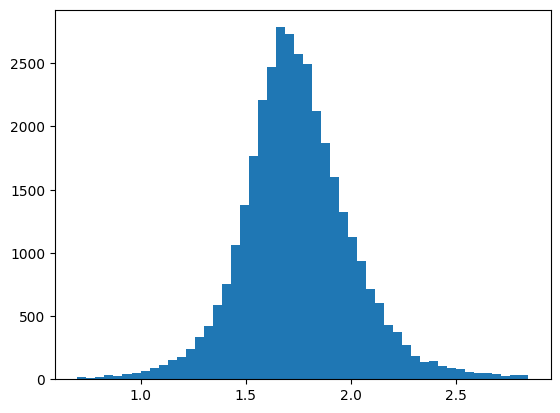

In [29]:
plt.hist(np.log10(dp_components[dp_components['N_COMP']!=1]['SIGMA'].unique()), bins=50)

plt.show()

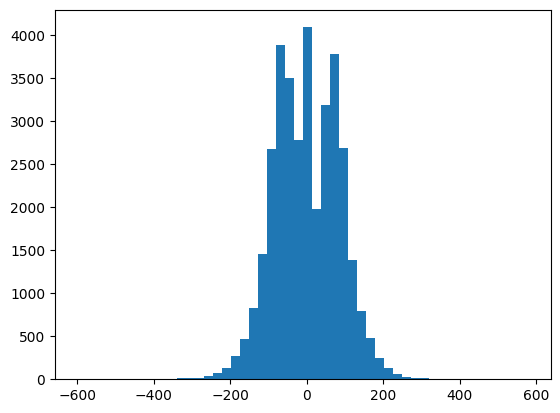

In [30]:
plt.hist((dp_components[dp_components['N_COMP']!=1]['DV'].unique()), bins=50)

plt.show()

## Eyeball a fit
Overlay data, total model, and every component for one target.

plotting TARGETID 39627739937902327  N_COMP = 4


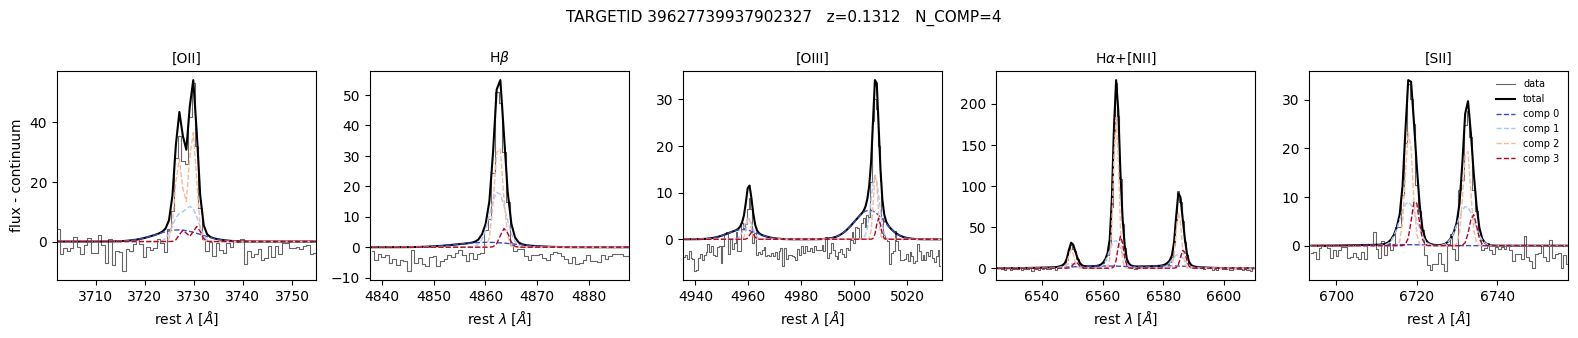

In [31]:
# prefer a multi-component target if we found one
if len(dp_sample):
    tid = int(dp_sample.sort_values('N_COMP', ascending=False)['TARGETID'].iloc[1])
else:
    tid = int(dp_parent['TARGETID'].iloc[0])
# tid = 39627793775986614
print('plotting TARGETID', tid, ' N_COMP =', int(dp_parent.loc[dp_parent['TARGETID']==tid, 'N_COMP'].iloc[0]))
fig, axes = DP.plot_fit(ALL_SPECTRA, dp_parent, dp_components, id=tid)
plt.show()

## Inspect the schema

In [32]:
print('parent columns:')
print(list(dp_parent.columns))
print()
print('component columns:')
print(list(dp_components.columns))

parent columns:
['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'N_COMP', 'N_COMP_FIT', 'BIC_1', 'CHISQ_1', 'BIC_2', 'CHISQ_2', 'BIC_3', 'CHISQ_3', 'BIC_4', 'CHISQ_4', 'OII3726_FLUX_TOT', 'OII3729_FLUX_TOT', 'Hbeta_FLUX_TOT', 'OIII4959_FLUX_TOT', 'OIII5007_FLUX_TOT', 'NII6548_FLUX_TOT', 'NII6583_FLUX_TOT', 'Halpha_FLUX_TOT', 'SII6716_FLUX_TOT', 'SII6731_FLUX_TOT', 'LOGSFR_FIT']

component columns:
['TARGETID', 'N_COMP', 'COMP_IDX', 'LINE', 'LAM0', 'DV', 'SIGMA', 'AMP', 'FLUX', 'FLUX_ERR', 'SNR', 'SIG', 'NOISE3', 'COMP_INSIG', 'BPT', 'OIII_HB_BOUND', 'NII_HA_BOUND']
